## Import Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, StratifiedKFold, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, recall_score, accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn import set_config
set_config(transform_output="pandas")
warnings.filterwarnings('ignore')

In [2]:
import dagshub
dagshub.init(repo_owner='Ankitkumar1141', repo_name='Churn-modelling', mlflow=True)

Accessing as Ankitkumar1141

Initialized MLflow to track repo "Ankitkumar1141/Churn-modelling"

Repository Ankitkumar1141/Churn-modelling initialized!

In [3]:
import mlflow

mlflow.set_tracking_uri('https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow')
mlflow.set_experiment('Experiment 2 - Balance Missing Indicator')

<Experiment: artifact_location='mlflow-artifacts:/ab74392d92a0426d85996369e7d55b4f', creation_time=1789828869298, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1789828869298, lifecycle_stage='active', name='Experiment 2 - Balance Missing Indicator', tags={}, trace_location=None, workspace='default'>

## Load the Preprocessed Data

In [4]:
df = pd.read_csv("preprocessed.csv")

In [5]:
print('Shape:', df.shape)

Shape: (10000, 37)


In [6]:
df.head(3)

,customer_id,name,gender,age,salary,location_id,churned,account_id,tenure,balance,...,is_single_product,inactive_senior,engagement_score,high_risk_inactive,is_female,geo_france,geo_germany,geo_spain,geo_uk,geo_usa
0,15634602,Hargrave,female,42,101348.88,2,1,A15634602SID,2,NaN,...,1,0,0.750000,0,1,1,0,0,0,0
1,15647311,Hill,female,41,112542.58,6,0,A15647311SID,1,83807.86,...,1,0,0.416667,0,1,0,0,0,0,1
2,15619304,Onio,female,42,113931.57,4,1,A15619304SID,8,159660.80,...,0,0,0.583333,0,1,0,0,0,1,0


## Exploratory Checks

In [7]:
df.dtypes

customer_id                  int64
name                        object
gender                      object
age                          int64
salary                     float64
location_id                  int64
churned                      int64
account_id                  object
tenure                       int64
balance                    float64
num_products                 int64
has_credit_card              int64
is_active                    int64
geography                   object
age_group                   object
salary_bracket              object
tenure_group                object
has_balance                  int64
churn_label                 object
has_credit_card_label       object
is_active_label             object
balance_to_salary          float64
balance_per_product        float64
age_when_joined              int64
products_per_tenure        float64
is_senior_risk               int64
is_extreme_product_risk      int64
is_single_product            int64
inactive_senior     

In [8]:
# Only 'balance' should have missing values
df.isna().sum().sort_values(ascending=False).head(5)

balance        3617
name              0
gender            0
age               0
customer_id       0
dtype: int64

In [9]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


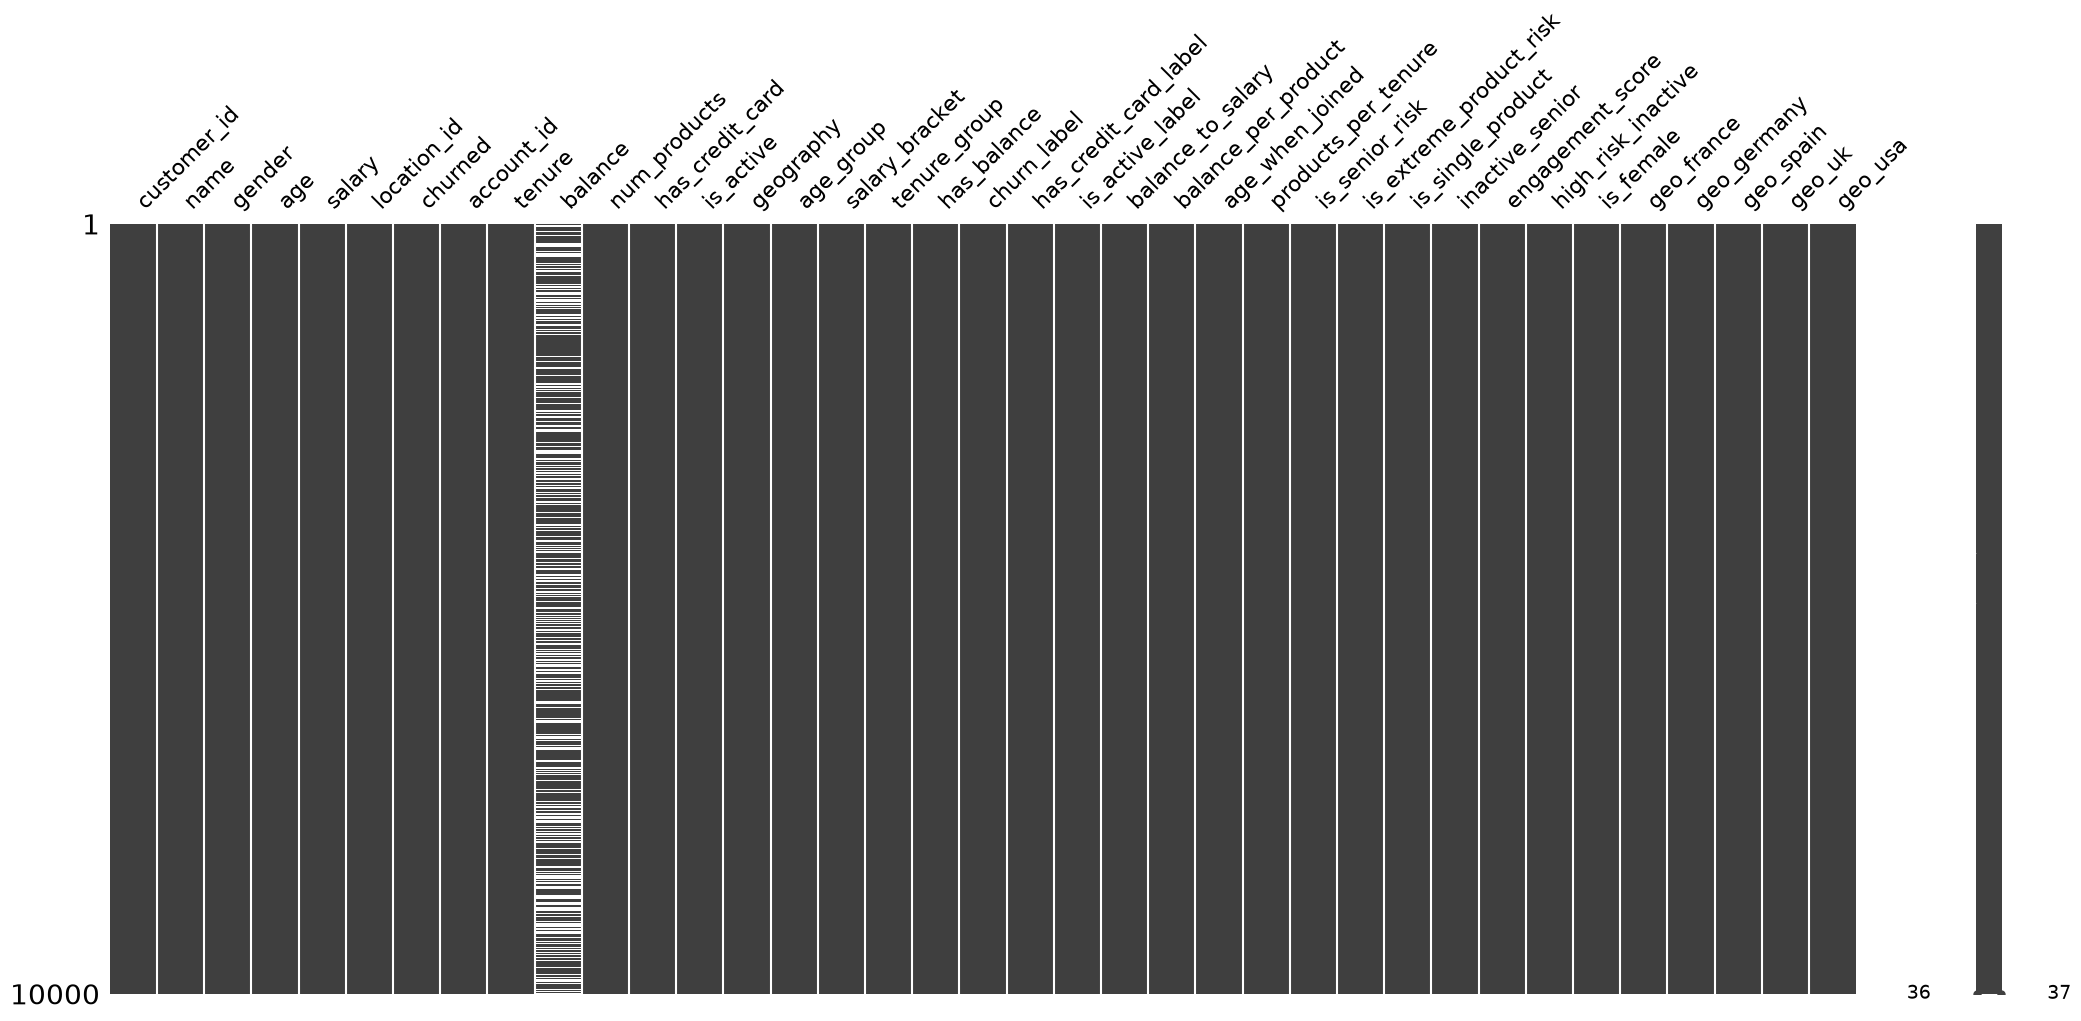

In [10]:
# Missing-value matrix — only Balance has nulls (36.17%)
msno.matrix(df)
plt.tight_layout()
plt.show()

In [11]:
print(df["churned"].value_counts())

churned
0    7963
1    2037
Name: count, dtype: int64


In [12]:
churn_rate = df["churned"].mean()
print('\nChurn rate: {:.2%}'.format(churn_rate))


Churn rate: 20.37%


## Drop Unnecessary Columns

- Drop identifier columns: `customer_id`, `account_id`, `name`, `location_id`
- Drop engineered label/text columns: `churn_label`, `has_credit_card_label`, `is_active_label`
- Drop already-encoded geo dummies — `geography` column will be encoded by the pipeline
- Drop `has_balance` — its information is captured by the `MissingIndicator` in this experiment
- Drop columns that showed very weak predictive signal in EDA: `salary`, `tenure`

In [13]:
drop_columns = [
    'has_balance',
    'products_per_tenure',
    'has_credit_card',
    'geo_france', 'geo_uk', 'geo_usa', 'geo_spain', 'geo_germany',
    'tenure', 'salary',
    'customer_id',
    'account_id', 'name', 'location_id',
    'age_when_joined', 'age',
    'churn_label',
    'has_credit_card_label',
    'is_active_label',
    "is_female"
]

df = df.drop(columns=drop_columns)
print('Shape after dropping columns:', df.shape)
df.head(3)

Shape after dropping columns: (10000, 17)


,gender,churned,balance,num_products,is_active,geography,age_group,salary_bracket,tenure_group,balance_to_salary,balance_per_product,is_senior_risk,is_extreme_product_risk,is_single_product,inactive_senior,engagement_score,high_risk_inactive
0,female,1,NaN,1,1,france,36-45,high,new (0-2),0.000000,0.000000,0,0,1,0,0.750000,0
1,female,0,83807.86,1,1,usa,36-45,high,new (0-2),0.744670,83807.860000,0,0,1,0,0.416667,0
2,female,1,159660.80,3,0,uk,36-45,high,veteran (8-10),1.401362,53220.266667,0,1,0,0,0.583333,0


In [14]:
df.head(3)

,gender,churned,balance,num_products,is_active,geography,age_group,salary_bracket,tenure_group,balance_to_salary,balance_per_product,is_senior_risk,is_extreme_product_risk,is_single_product,inactive_senior,engagement_score,high_risk_inactive
0,female,1,NaN,1,1,france,36-45,high,new (0-2),0.000000,0.000000,0,0,1,0,0.750000,0
1,female,0,83807.86,1,1,usa,36-45,high,new (0-2),0.744670,83807.860000,0,0,1,0,0.416667,0
2,female,1,159660.80,3,0,uk,36-45,high,veteran (8-10),1.401362,53220.266667,0,1,0,0,0.583333,0


In [15]:
# Confirm which column still has missing values
missing_cols = df.isna().any(axis=0).loc[lambda x: x].index.tolist()
print('Columns with missing values:', missing_cols)

Columns with missing values: ['balance']


In [16]:
print('Missing count:', df[missing_cols].isna().sum().to_dict())

Missing count: {'balance': 3617}


In [17]:
# Percentage of rows that have at least one missing value
pct_missing_rows = df.isna().any(axis=1).mean().round(4) * 100
print(f'Rows with missing values: {pct_missing_rows:.2f}%  ({df.isna().any(axis=1).sum():,} rows)')

Rows with missing values: 36.17%  (3,617 rows)


## Train / Test Split

In [18]:
X = df.drop(columns="churned")
y = df["churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,     # preserve churn ratio in both splits
)

print('Train size : {:,}  |  churn rate: {:.2%}'.format(X_train.shape[0], y_train.mean()))
print('Test  size : {:,}  |  churn rate: {:.2%}'.format(X_test.shape[0], y_test.mean()))

Train size : 8,000  |  churn rate: 20.38%
Test  size : 2,000  |  churn rate: 20.35%


In [19]:
print('Train shape:', X_train.shape)
print('Test  shape:', X_test.shape)

Train shape: (8000, 16)
Test  shape: (2000, 16)


In [20]:
# Missing values inside the training split
X_train.isna().sum()[X_train.isna().sum() > 0]

balance    2891
dtype: int64

In [21]:
X_train.columns.tolist()

['gender',
 'balance',
 'num_products',
 'is_active',
 'geography',
 'age_group',
 'salary_bracket',
 'tenure_group',
 'balance_to_salary',
 'balance_per_product',
 'is_senior_risk',
 'is_extreme_product_risk',
 'is_single_product',
 'inactive_senior',
 'engagement_score',
 'high_risk_inactive']

In [22]:
numeric_cols     = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
binary_cols      = [c for c in numeric_cols if X[c].nunique() == 2]
scale_cols       = [c for c in numeric_cols if c not in binary_cols]

# 'balance' is the only column with NaN — it is in scale_cols
balance_col = ['balance']
scale_cols_no_balance = [c for c in scale_cols if c != 'balance']

print('Numeric (to scale, no balance) :', scale_cols_no_balance)
print('Balance col (impute+indicator) :', balance_col)
print('Binary (passthrough)           :', binary_cols)
print('Categorical (OHE)              :', categorical_cols)

Numeric (to scale, no balance) : ['num_products', 'balance_to_salary', 'balance_per_product', 'engagement_score']
Balance col (impute+indicator) : ['balance']
Binary (passthrough)           : ['is_active', 'is_senior_risk', 'is_extreme_product_risk', 'is_single_product', 'inactive_senior', 'high_risk_inactive']
Categorical (OHE)              : ['gender', 'geography', 'age_group', 'salary_bracket', 'tenure_group']


In [23]:
# Step 1: Impute balance median + add missing indicator via ColumnTransformer
# We build a mini sub-transformer for the balance column only

balance_imputer = ColumnTransformer(
    transformers=[
        (
            'balance_impute_and_flag',
            SimpleImputer(strategy='median', add_indicator=True),
            balance_col
        ),
    ],
    remainder='passthrough',
    n_jobs=-1,
    verbose_feature_names_out=False,
)

balance_imputer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('balance_impute_and_flag', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per trans

In [24]:
# Verify the imputer produces the indicator column
temp = balance_imputer.fit_transform(X_train)
print('Output shape after imputation step:', temp.shape)
print('Columns:', temp.columns.tolist())

Output shape after imputation step: (8000, 17)
Columns: ['balance', 'missingindicator_balance', 'gender', 'num_products', 'is_active', 'geography', 'age_group', 'salary_bracket', 'tenure_group', 'balance_to_salary', 'balance_per_product', 'is_senior_risk', 'is_extreme_product_risk', 'is_single_product', 'inactive_senior', 'engagement_score', 'high_risk_inactive']


In [25]:
# Confirm no missing values remain after imputation
print('Missing values after imputation step:')
print(temp.isna().sum()[temp.isna().sum() > 0])
print('No missing values:', temp.isna().sum().sum() == 0)

Missing values after imputation step:
Series([], dtype: int64)
No missing values: True


In [26]:
# Check that the indicator flag correctly marks originally-missing rows
indicator_col = [c for c in temp.columns if 'missingindicator' in c.lower() or 'missing' in c.lower()]
print('Indicator column(s):', indicator_col)
if indicator_col:
    print('Flag value counts (1=was missing):')
    print(temp[indicator_col[0]].value_counts())

Indicator column(s): ['missingindicator_balance']
Flag value counts (1=was missing):
missingindicator_balance
0.0    5109
1.0    2891
Name: count, dtype: int64


## Full Preprocessing Pipeline

In [27]:

after_impute_cols = balance_imputer.fit_transform(X_train).columns.tolist()
indicator_col_name = [c for c in after_impute_cols if 'missing' in c.lower()][0]
print('Indicator column name:', indicator_col_name)


scale_after = [c for c in after_impute_cols
               if c in scale_cols_no_balance + balance_col]
cat_after = [c for c in after_impute_cols if c in categorical_cols]
binary_after = [c for c in after_impute_cols
                if c in binary_cols or c == indicator_col_name]

print('\nScale cols :', scale_after)
print('Cat cols   :', cat_after)
print('Binary cols:', binary_after)

Indicator column name: missingindicator_balance

Scale cols : ['balance', 'num_products', 'balance_to_salary', 'balance_per_product', 'engagement_score']
Cat cols   : ['gender', 'geography', 'age_group', 'salary_bracket', 'tenure_group']
Binary cols: ['missingindicator_balance', 'is_active', 'is_senior_risk', 'is_extreme_product_risk', 'is_single_product', 'inactive_senior', 'high_risk_inactive']


In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        ('scale', MinMaxScaler(), scale_after),
        ('nominal_encode',
         OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
         cat_after),
    ],
    remainder='passthrough',   # binary cols + indicator col pass through
    n_jobs=-1,
    verbose_feature_names_out=False,
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale', ...), ('nominal_encode', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features pe

In [29]:
processing_pipeline = Pipeline(steps=[
    ('balance_imputer', balance_imputer),
    ('preprocessor', preprocessor),
])

processing_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('balance_imputer', ...), ('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('balance_impute_and_flag', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"n_jobs n_jobs: int, default=NoneNumb

In [30]:
X_train_transformed = processing_pipeline.fit_transform(X_train)
X_test_transformed  = processing_pipeline.transform(X_test)

print('X_train transformed shape:', X_train_transformed.shape)
print('X_test  transformed shape:', X_test_transformed.shape)
print('Any NaN after pipeline    :', X_train_transformed.isna().sum().sum())

X_train transformed shape: (8000, 28)
X_test  transformed shape: (2000, 28)
Any NaN after pipeline    : 0


In [31]:
X_train_transformed.head(3)

,balance,num_products,balance_to_salary,balance_per_product,engagement_score,gender_male,geography_france,geography_germany,geography_spain,geography_uk,...,tenure_group_new (0-2),tenure_group_senior (6-7),tenure_group_veteran (8-10),missingindicator_balance,is_active,is_senior_risk,is_extreme_product_risk,is_single_product,inactive_senior,high_risk_inactive
2151,0.494500,0.000000,0.000000,0.000000,0.363636,1.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0,1,0,1,1,0
8392,0.419231,0.000000,0.000163,0.428413,0.363636,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0,0,0,1,0,0
5006,0.469257,0.333333,0.000099,0.238824,0.818182,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1,0,0,0,0,0


### Model Training

In [32]:
rf = RandomForestClassifier(random_state=42)

model_pipe = Pipeline(steps=[
    ('processing', processing_pipeline),
    ('classifier', rf),
])

model_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('processing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('balance_imputer', ...), ('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameter

In [33]:
model_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('processing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['gender','balance','num_products',...,'inactive_senior', 'engagement_score','high_risk_inactive']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('balance_imputer', ...), ('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance g

In [34]:
# Predictions
y_pred_train = model_pipe.predict(X_train)
y_pred_test  = model_pipe.predict(X_test)

In [35]:
# Metrics
roc_auc_c  = roc_auc_score(y_test, y_pred_test)
recall_c   = recall_score(y_test, y_pred_test)
accuracy_c = accuracy_score(y_test, y_pred_test)

print(f'Train accuracy : {accuracy_score(y_train, y_pred_train):.4f}')
print(f'Test  accuracy : {accuracy_c:.4f}')
print(f'Train recall   : {recall_score(y_train, y_pred_train):.4f}')
print(f'Test  recall   : {recall_c:.4f}')
print(f'Train ROC-AUC  : {roc_auc_score(y_train, y_pred_train):.4f}')
print(f'Test  ROC-AUC  : {roc_auc_c:.4f}')

Train accuracy : 0.9934
Test  accuracy : 0.8475
Train recall   : 0.9736
Test  recall   : 0.4423
Train ROC-AUC  : 0.9860
Test  ROC-AUC  : 0.6966


In [37]:
print("\n=== Classification Report (Test Set) ===")
print(classification_report(
    y_test, y_pred_test
))


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      1593
           1       0.70      0.44      0.54       407

    accuracy                           0.85      2000
   macro avg       0.78      0.70      0.72      2000
weighted avg       0.83      0.85      0.83      2000



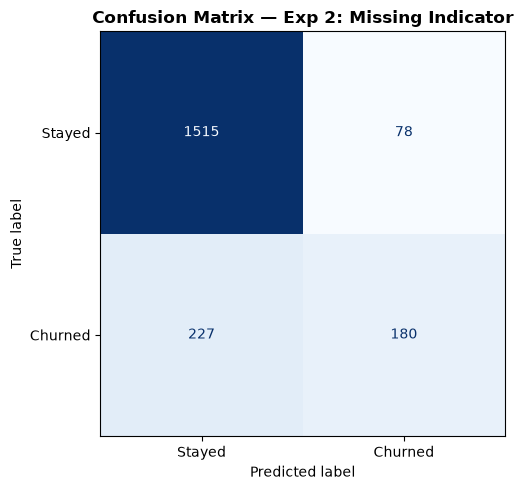

In [38]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Exp 2: Missing Indicator', fontweight='bold')
plt.tight_layout()
plt.show()

## Cross-Validation

In [39]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'roc_auc' : 'roc_auc',
    'recall'  : 'recall',
    'accuracy': 'accuracy',
}

In [40]:
cv_results = cross_validate(
    model_pipe,
    X_train,       # raw X_train — pipeline handles imputation internally
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1,
)

results_df = pd.DataFrame(cv_results)
results_df

,fit_time,score_time,test_roc_auc,train_roc_auc,test_recall,train_recall,test_accuracy,train_accuracy
0,0.897043,0.182924,0.806797,0.999786,0.420245,0.980061,0.831875,0.994375
1,0.865978,0.191154,0.833768,0.999825,0.432515,0.978528,0.840625,0.995156
2,0.884939,0.184544,0.832824,0.999717,0.463190,0.972393,0.843125,0.993437
3,0.878326,0.189019,0.786840,0.999724,0.411043,0.976994,0.835625,0.994375
4,0.876359,0.185582,0.799496,0.999832,0.420245,0.980061,0.829375,0.994844


In [41]:
print('=== CV Summary (5-Fold Stratified) ===')
print(f"Mean CV ROC-AUC  : {results_df['test_roc_auc'].mean():.4f} ± {results_df['test_roc_auc'].std():.4f}")
print(f"Mean CV Recall   : {results_df['test_recall'].mean():.4f} ± {results_df['test_recall'].std():.4f}")
print(f"Mean CV Accuracy : {results_df['test_accuracy'].mean():.4f} ± {results_df['test_accuracy'].std():.4f}")

=== CV Summary (5-Fold Stratified) ===
Mean CV ROC-AUC  : 0.8119 ± 0.0208
Mean CV Recall   : 0.4294 ± 0.0203
Mean CV Accuracy : 0.8361 ± 0.0058


## Log Experiment to MLflow

In [42]:
with mlflow.start_run(run_name='Missing Indicator'):

    mlflow.log_param('experiment_type', 'Missing Indicator')
    mlflow.log_param('imputer_strategy', 'median + MissingIndicator')
    mlflow.log_param('dataset_rows', X.shape[0])
    mlflow.log_param('dataset_features', X.shape[1])
    mlflow.log_params(rf.get_params())
    mlflow.log_metric('training_accuracy', accuracy_score(y_train, y_pred_train))
    mlflow.log_metric('training_recall',   recall_score(y_train, y_pred_train))
    mlflow.log_metric('training_roc_auc',  roc_auc_score(y_train, y_pred_train))
    mlflow.log_metric('test_accuracy', accuracy_c)
    mlflow.log_metric('test_recall',   recall_c)
    mlflow.log_metric('test_roc_auc',  roc_auc_c)
    mlflow.log_metric('cv_mean_roc_auc',  results_df['test_roc_auc'].mean())
    mlflow.log_metric('cv_mean_recall',   results_df['test_recall'].mean())
    mlflow.log_metric('cv_mean_accuracy', results_df['test_accuracy'].mean())
    for i, score in enumerate(results_df['test_roc_auc']):
        mlflow.log_metric('cv_roc_auc_fold', score, step=i)
    for i, score in enumerate(results_df['test_recall']):
        mlflow.log_metric('cv_recall_fold', score, step=i)

    print('MLflow run logged successfully.')

MLflow run logged successfully.
🏃 View run Missing Indicator at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/1/runs/ad6c3734afe84bfe8eed92c33aea0418
🧪 View experiment at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/1


In [43]:
# Quick summary table for this experiment
summary = pd.DataFrame({
    'Metric': ['Test ROC-AUC', 'Test Recall', 'Test Accuracy',
               'CV ROC-AUC (mean)', 'CV Recall (mean)', 'CV Accuracy (mean)'],
    'Exp 2 — Missing Indicator': [
        round(roc_auc_c, 4),
        round(recall_c, 4),
        round(accuracy_c, 4),
        round(results_df['test_roc_auc'].mean(), 4),
        round(results_df['test_recall'].mean(), 4),
        round(results_df['test_accuracy'].mean(), 4),
    ]
})
summary

,Metric,Exp 2 — Missing Indicator
0,Test ROC-AUC,0.6966
1,Test Recall,0.4423
2,Test Accuracy,0.8475
3,CV ROC-AUC (mean),0.8119
4,CV Recall (mean),0.4294
5,CV Accuracy (mean),0.8361
